EXPLORATORY DATA ANALYSIS - CREDIT RISK
Data loaded successfully from UCI

FIRST 5 ROWS:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000  

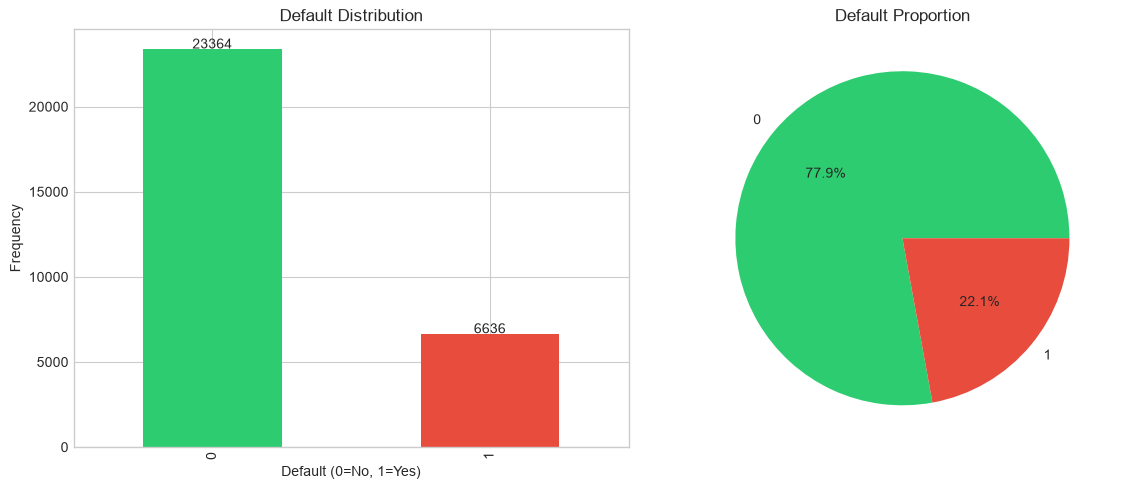


Default distribution:
  No default (0): 23364 (77.9%)
  Default (1):    6636 (22.1%)


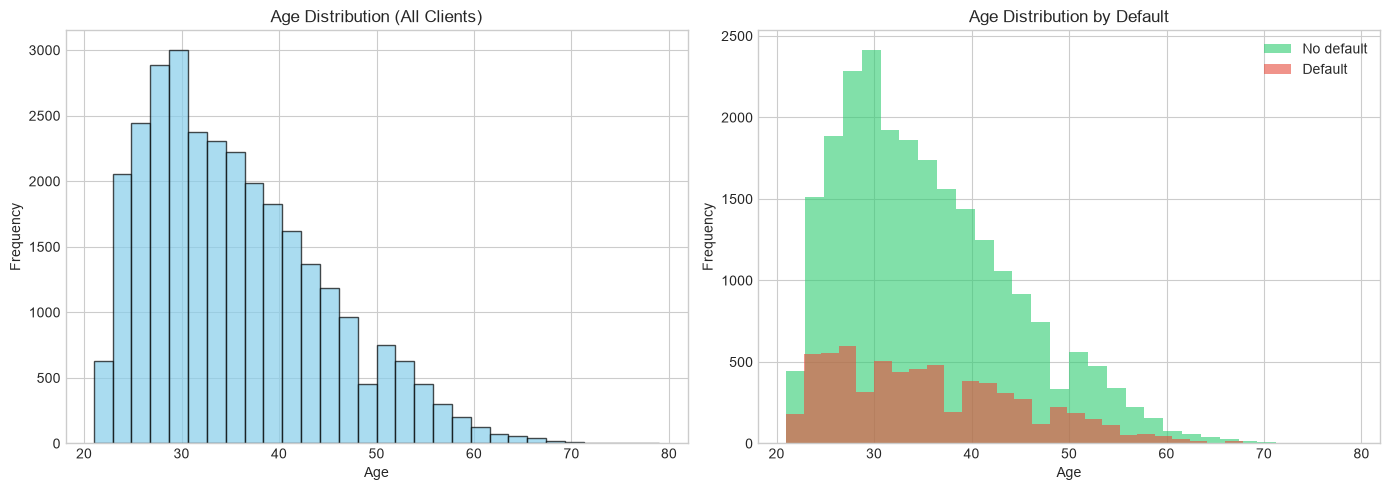


Age statistics:
  Average: 35.5 years
  Median:  34 years
  Min:     21 years
  Max:     79 years


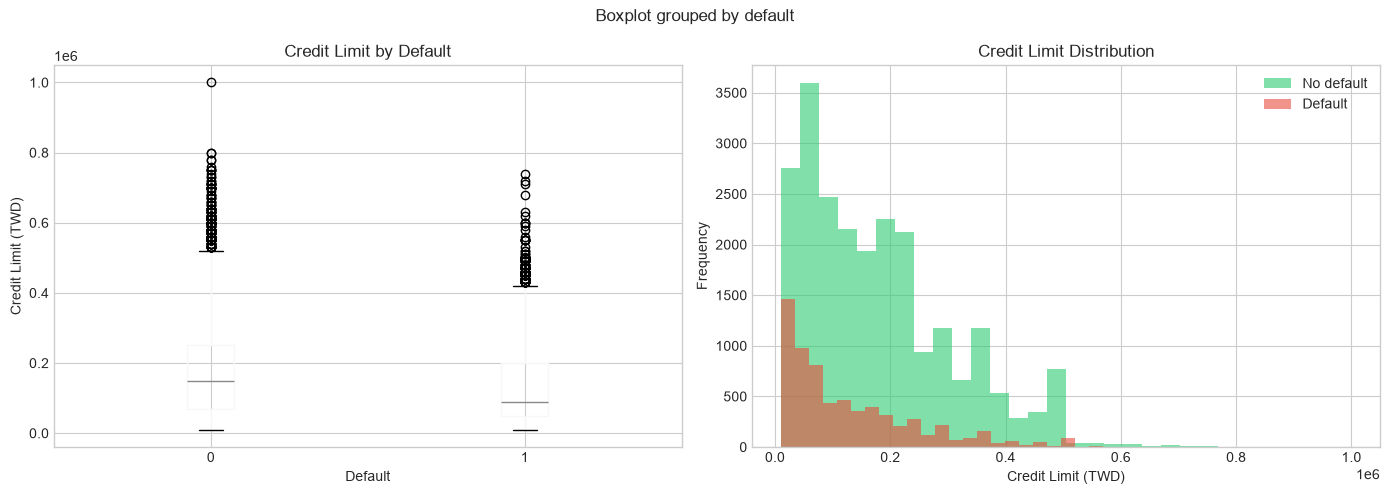


Average credit limit:
  No default: 178100 TWD
  Default:    130110 TWD

CORRELATION MATRIX


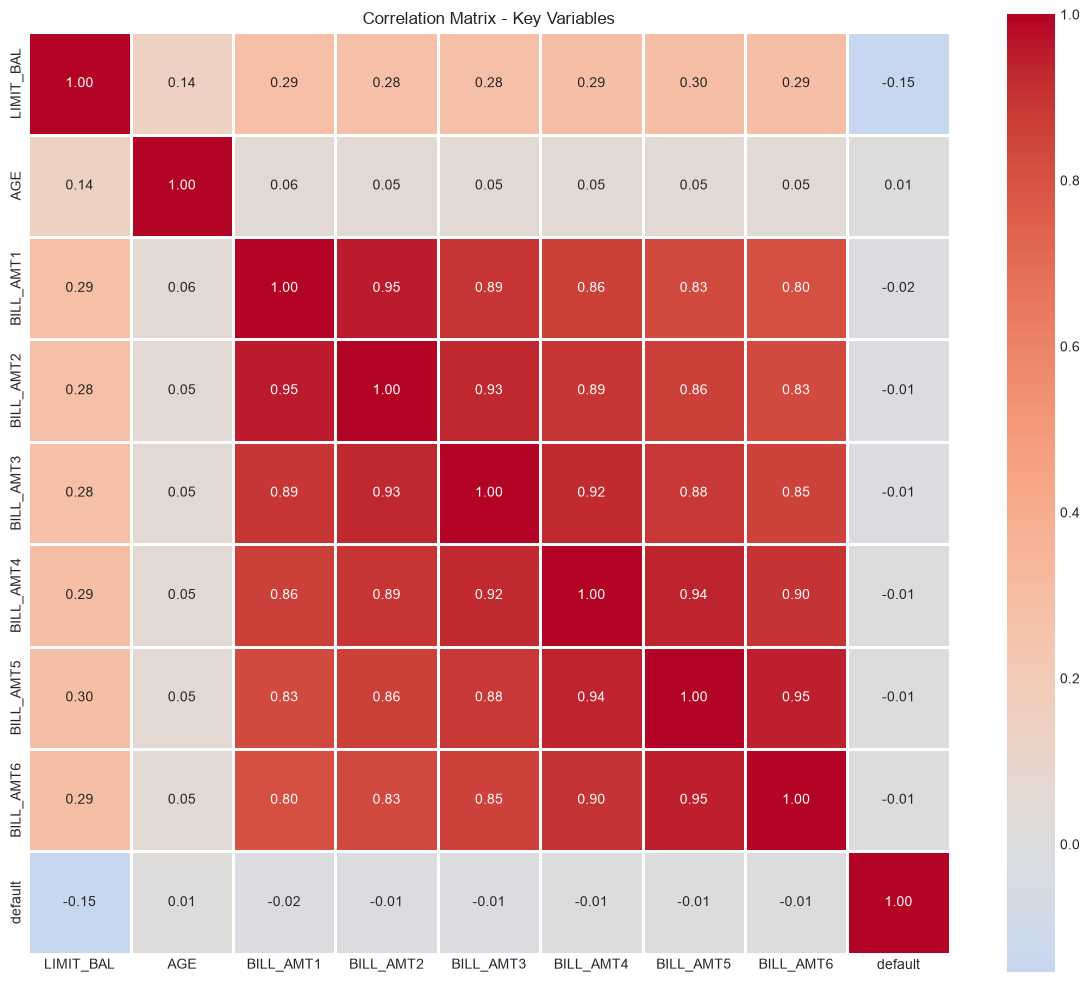


Correlations with default:
default      1.000000
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
LIMIT_BAL   -0.153520
Name: default, dtype: float64

KEY FINDINGS

1. Imbalanced dataset: 22.1% defaults, 77.9% non-defaults.
   → Requires class weighting or resampling.

2. Default clients have lower average credit limits.
   → LIMIT_BAL serves as a solvency proxy.

3. Payment variables (PAY_0, PAY_2, etc.) show strong correlation.
   → Recent payment history is the strongest predictor.

4. Age shows minimal correlation with default.
   → Not a strong risk indicator.

5. Billing variables (BILL_AMT) show moderate correlation.
   → Useful but secondary to payment history.

Modeling recommendations:
   - Use PAY_0 as the primary feature.
   - Include LIMIT_BAL and billing variables.
   - Apply SMOTE or class weights to handle imbalance.


EDA COMPLETED. Figures saved in outputs/figures

In [1]:
# =====================================================
# 01_EDA - Credit Risk Exploratory Data Analysis
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*60)
print("EXPLORATORY DATA ANALYSIS - CREDIT RISK")
print("="*60)

# =====================================================
# 1. DATA LOADING
# =====================================================

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

try:
    df_raw = pd.read_excel(URL, header=1, skiprows=0)
    print("Data loaded successfully from UCI")
except Exception as e:
    print(f"Error loading from UCI: {e}")
    try:
        df_raw = pd.read_excel('data/raw/default_credit.xls', header=1)
        print("Data loaded from local file")
    except:
        raise FileNotFoundError(
            "Download dataset from: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients"
        )

# =====================================================
# 2. INITIAL CLEANING
# =====================================================

print("\nFIRST 5 ROWS:")
print(df_raw.head())

print("\nDATASET INFO:")
print(df_raw.info())

print("\nDESCRIPTIVE STATISTICS:")
print(df_raw.describe())

# =====================================================
# 3. NULL VALUES AND DUPLICATES
# =====================================================

print("\nNULL VALUES BY COLUMN:")
print(df_raw.isnull().sum())

print(f"\nDUPLICATE RECORDS: {df_raw.duplicated().sum()}")

# =====================================================
# 4. PREPROCESSING
# =====================================================

df = df_raw.copy()
df.columns = [
    'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'default'
]

df['default'] = df['default'].astype(int)
df['SEX'] = df['SEX'].astype('category')
df['EDUCATION'] = df['EDUCATION'].astype('category')
df['MARRIAGE'] = df['MARRIAGE'].astype('category')

print("\nDEFAULT DISTRIBUTION:")
print(df['default'].value_counts())

# =====================================================
# 5. EXPLORATORY ANALYSIS
# =====================================================

print("\n" + "="*60)
print("EXPLORATORY ANALYSIS")
print("="*60)

# 5.1 Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
df['default'].value_counts().plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Default Distribution')
ax1.set_xlabel('Default (0=No, 1=Yes)')
ax1.set_ylabel('Frequency')
for i, v in enumerate(df['default'].value_counts().values):
    ax1.text(i, v + 50, str(v), ha='center')

ax2 = axes[1]
df['default'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', 
                                   colors=['#2ecc71', '#e74c3c'])
ax2.set_title('Default Proportion')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('outputs/figures/default_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDefault distribution:")
print(f"  No default (0): {df['default'].value_counts()[0]} ({df['default'].value_counts()[0]/len(df)*100:.1f}%)")
print(f"  Default (1):    {df['default'].value_counts()[1]} ({df['default'].value_counts()[1]/len(df)*100:.1f}%)")

# 5.2 Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
df['AGE'].hist(bins=30, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Age Distribution (All Clients)')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')

ax2 = axes[1]
df[df['default']==0]['AGE'].hist(bins=30, alpha=0.6, label='No default', color='#2ecc71', ax=ax2)
df[df['default']==1]['AGE'].hist(bins=30, alpha=0.6, label='Default', color='#e74c3c', ax=ax2)
ax2.set_title('Age Distribution by Default')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.savefig('outputs/figures/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAge statistics:")
print(f"  Average: {df['AGE'].mean():.1f} years")
print(f"  Median:  {df['AGE'].median():.0f} years")
print(f"  Min:     {df['AGE'].min():.0f} years")
print(f"  Max:     {df['AGE'].max():.0f} years")

# 5.3 Credit Limit Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
df.boxplot(column='LIMIT_BAL', by='default', ax=ax1)
ax1.set_title('Credit Limit by Default')
ax1.set_xlabel('Default')
ax1.set_ylabel('Credit Limit (TWD)')

ax2 = axes[1]
df[df['default']==0]['LIMIT_BAL'].hist(bins=30, alpha=0.6, label='No default', color='#2ecc71', ax=ax2)
df[df['default']==1]['LIMIT_BAL'].hist(bins=30, alpha=0.6, label='Default', color='#e74c3c', ax=ax2)
ax2.set_title('Credit Limit Distribution')
ax2.set_xlabel('Credit Limit (TWD)')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.savefig('outputs/figures/credit_limit_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAverage credit limit:")
print(f"  No default: {df[df['default']==0]['LIMIT_BAL'].mean():.0f} TWD")
print(f"  Default:    {df[df['default']==1]['LIMIT_BAL'].mean():.0f} TWD")

# =====================================================
# 6. CORRELATION MATRIX
# =====================================================

print("\n" + "="*60)
print("CORRELATION MATRIX")
print("="*60)

numeric_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'default']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix - Key Variables')
plt.tight_layout()
plt.savefig('outputs/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelations with default:")
print(corr_matrix['default'].sort_values(ascending=False))

# =====================================================
# 7. KEY FINDINGS
# =====================================================

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

print("""
1. Imbalanced dataset: 22.1% defaults, 77.9% non-defaults.
   → Requires class weighting or resampling.

2. Default clients have lower average credit limits.
   → LIMIT_BAL serves as a solvency proxy.

3. Payment variables (PAY_0, PAY_2, etc.) show strong correlation.
   → Recent payment history is the strongest predictor.

4. Age shows minimal correlation with default.
   → Not a strong risk indicator.

5. Billing variables (BILL_AMT) show moderate correlation.
   → Useful but secondary to payment history.

Modeling recommendations:
   - Use PAY_0 as the primary feature.
   - Include LIMIT_BAL and billing variables.
   - Apply SMOTE or class weights to handle imbalance.
""")

print("\nEDA COMPLETED. Figures saved in outputs/figures/")